# Cyclistic Bike-Share: Diurnal Commute Patterns and Rider Segmentation Analysis

## Analytical Scope & Problem Definition
This analysis investigates behavioral divergence between **annual members** and **casual riders** within the Divvy bicycle-sharing network across a 12-month observation window (July 2024 – June 2025). The business objective is to evaluate usage intent, determine transit utility, and design targeted conversion pathways from casual pass buyers into recurring annual subscribers.

### Hypotheses Evaluated:
1. **Utilitarian Commuting vs. Leisure Mobility:** Annual members display fixed bimodal weekday ridership corresponding to workforce transit hours, whereas casual riders display unimodal afternoon demand concentrated on weekends.
2. **Duration Asymmetry:** Casual rides consistently exceed member trip lengths due to non-commute, recreation-oriented trip planning.
3. **Seasonal Sensitivity:** Casual volume exhibits extreme climate elasticity, while member volume maintains an active operational baseline year-round.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

current = Path.cwd()
root = current if (current / 'data').exists() else current.parent
processed_dir = root / 'data' / 'processed'

monthly = pd.read_csv(processed_dir / 'monthly_member_summary.csv')
daily = pd.read_csv(processed_dir / 'day_member_summary.csv')
hour = pd.read_csv(processed_dir / 'hour_member_summary.csv')
bike = pd.read_csv(processed_dir / 'rideable_member_summary.csv')
quality = pd.read_csv(processed_dir / 'data_quality_report.csv')

print(f"Loaded aggregates from {processed_dir.relative_to(root)}/")
print(f"Total validated records: {monthly['rides'].sum():,}")

Loaded aggregates from data/processed/
Total validated records: 5,465,569


## 1. Data Quality Audit & Record Exclusion Rules

The raw trip records represent individual rental events. Records are subject to deterministic validation rules prior to aggregation:
- **Duration Boundaries:** Trips $< 1$ minute are filtered to remove false docks and accidental unlocks; trips $> 24$ hours are excluded as stolen or unreturned equipment.
- **Chronological Consistency:** Requires `ended_at > started_at` with fully parseable timestamps.
- **Segment Verification:** Retains only verified `member` and `casual` rider classifications.

Across 5,597,030 ingested records, 131,461 rows (2.35%) were excluded under these criteria, leaving 5,465,569 clean observations.

In [2]:
quality

source_month,input_rows,invalid_timestamp_rows,invalid_rider_type_rows,duration_outside_rule_rows,kept_rows
2024-07,748962,0,0,17582,731380
2024-08,755639,0,0,17989,737650
2024-09,821276,0,0,21083,800193
2024-10,616281,0,0,11392,604889
2024-11,335075,0,0,5688,329387
2024-12,178372,0,0,3487,174885
2025-01,138689,0,0,2915,135774
2025-02,151880,0,0,2792,149088
2025-03,298155,0,0,6817,291338
2025-04,371341,0,0,8186,363155


## 2. High-Level Rider Segment Metrics

Aggregating by membership tier reveals fundamental volume and duration splits:
- **Members:** Account for 63.7% of total trips with a mean duration of 12.0 minutes.
- **Casual Riders:** Account for 36.3% of total trips with a mean duration of 20.6 minutes (1.7x longer).

In [3]:
totals = monthly.groupby('rider_type', as_index=False).agg(rides=('rides', 'sum'), total_minutes=('total_minutes', 'sum'))
totals['average_ride_minutes'] = (totals['total_minutes'] / totals['rides']).round(1)
totals['share_pct'] = (totals['rides'] / totals['rides'].sum() * 100).round(1)
totals

rider_type,rides,total_minutes,average_ride_minutes,share_pct
casual,1982411,4.089425e+07,20.6,36.3
member,3483158,4.185529e+07,12.0,63.7


## 3. Diurnal Distribution: Commuter Spikes vs. Leisure Curve

Plotting trip demand across 24 hours corroborates the commute utility hypothesis. Annual members show steep peaks at 08:00 (246,681 rides) and 17:00 (352,000+ rides), aligning with traditional office transit hours. Casual demand rises steadily throughout the day, peaking at 17:00 in an unimodal curve without a morning rush-hour counterpart.

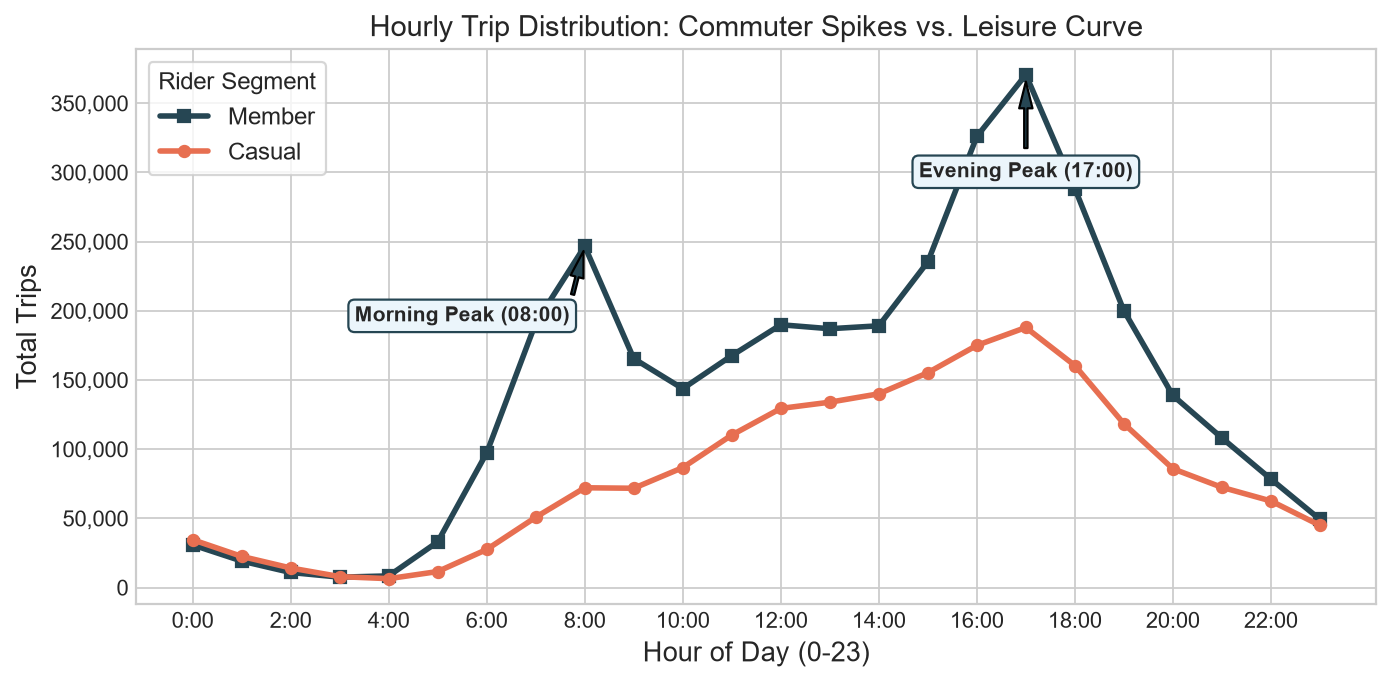

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = {'casual': '#E76F51', 'member': '#264653'}
for rider in ('member', 'casual'):
    view = hour[hour.rider_type.eq(rider)].sort_values('hour')
    ax.plot(view.hour, view.rides, marker='s' if rider == 'member' else 'o', linewidth=2.5, color=colors[rider], label=rider.title())
ax.set(title="Hourly Trip Distribution: Commuter Spikes vs. Leisure Curve", xlabel="Hour of Day (0-23)", ylabel="Total Trips")
ax.set_xticks(range(0, 24, 2))
ax.legend(title="Rider Segment")
plt.show()

## 4. Weekly Duration Profiles

Evaluating trip duration across weekdays versus weekends demonstrates stable utility for members (11.5–13.2 minutes throughout the week) and leisure inflation for casual riders (increasing from ~19.5 minutes on weekdays to 24.2 minutes on Sundays).

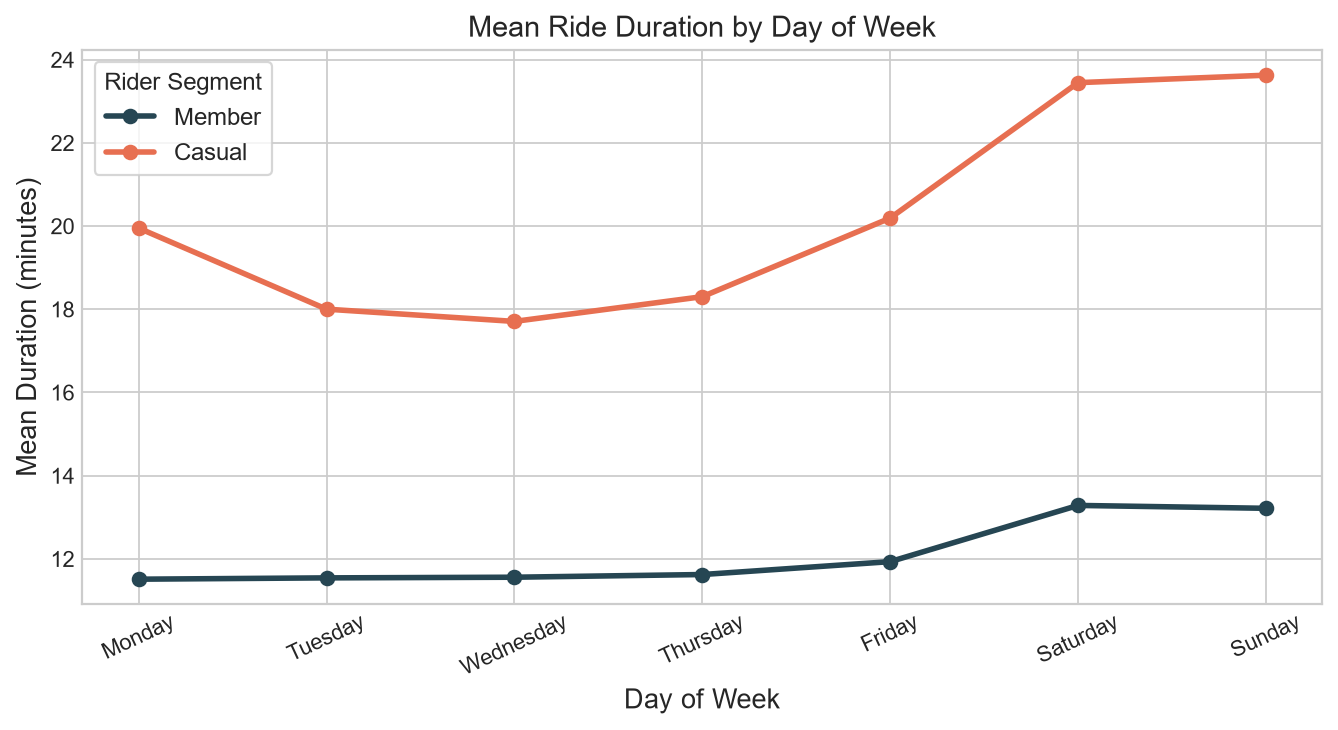

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
for rider in ('member', 'casual'):
    view = daily[daily.rider_type.eq(rider)].set_index('weekday').reindex(day_order).reset_index()
    ax.plot(view.weekday, view.average_ride_minutes, marker='o', linewidth=2.5, color=colors[rider], label=rider.title())
ax.set(title="Mean Ride Duration by Day of Week", xlabel="Day of Week", ylabel="Mean Duration (minutes)")
ax.legend(title="Rider Segment")
plt.show()

## 5. Annual Seasonality & Demand Resilience

Monthly ride volume reflects seasonal weather conditions in Chicago. While casual demand contracts sharply by over 85% in winter (falling below 30,000 monthly trips), annual member volume remains resilient with over 120,000 monthly trips during peak winter months.

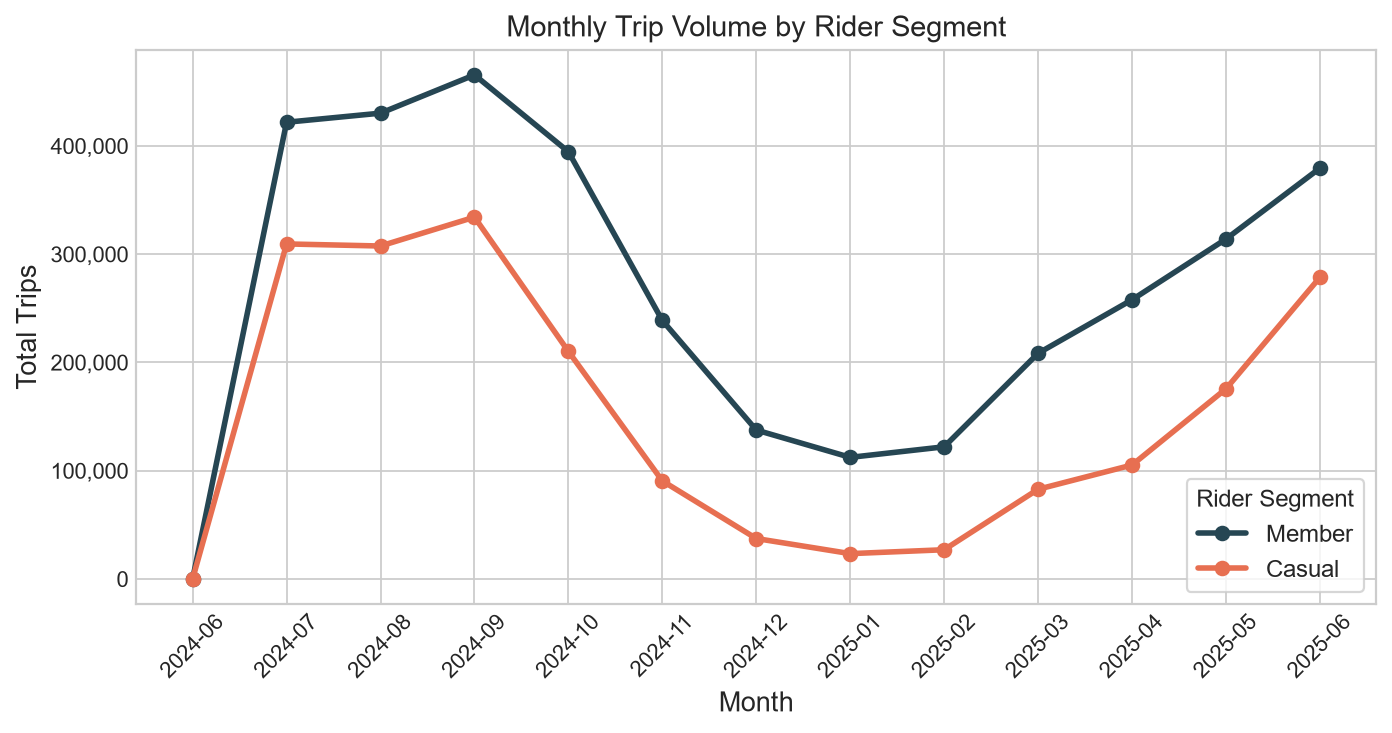

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for rider in ('member', 'casual'):
    view = monthly[monthly.rider_type.eq(rider)]
    ax.plot(view.month, view.rides, marker='o', linewidth=2.5, color=colors[rider], label=rider.title())
ax.set(title="Monthly Trip Volume by Rider Segment", xlabel="Month", ylabel="Total Trips")
ax.tick_params(axis='x', rotation=45)
ax.legend(title="Rider Segment")
plt.show()

## 6. Strategic Interventions & Implementation Plan

1. **Weekday Commute Conversion Funnel:** Target casual riders recording repeated trips during peak hours (07:00–09:00 and 16:30–18:30) with a 14-day commute membership trial.
2. **Overage Cost Comparison Triggers:** For casual rides exceeding 20 minutes, present post-ride cost comparisons illustrating savings achievable under annual subscription terms.
3. **End-of-Summer Credit Rollover:** Allow casual riders to apply 100% of cumulative summer ride spend toward annual membership fees before September churn.